# Hierarchical Clustering

## Overview

Hierarchical clustering builds a tree (dendrogram) of nested cluster merges. Unlike k-means, it does not require specifying k in advance and reveals structure at multiple scales simultaneously.

**Agglomerative** (bottom-up, most common): each observation starts as its own cluster; pairs are merged iteratively based on linkage distance until all observations are in one cluster.

**Linkage methods:**

| Linkage | Distance between clusters A and B | Properties |
|---|---|---|
| **Complete** | max distance between any pair | Compact, spherical clusters; sensitive to outliers |
| **Single** | min distance between any pair | Elongated clusters; chaining effect |
| **Average (UPGMA)** | mean of all pairwise distances | Compromise; good general default |
| **Ward.D2** | increase in total within-cluster SS | Similar to k-means; compact clusters; recommended for most purposes |
| **Centroid** | distance between cluster centroids | Can produce inversions in dendrogram |

**Distance metrics:**
- Euclidean: continuous features (scale first)
- Manhattan: robust to outliers
- Gower: mixed-type data (continuous + categorical)
- Bray-Curtis: species abundance data

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(cluster)       # agnes(), daisy() for Gower distance
library(factoextra)    # fviz_dend(), fviz_cluster()
library(dendextend)    # tanglegram(), color_branches()
library(patchwork)

set.seed(42)

n_per <- 60
hier_data <- bind_rows(
  tibble(nitrate=rnorm(n_per,2,0.6), water_qual=rnorm(n_per,8,0.8),
         phosphorus=rnorm(n_per,0.3,0.1), turbidity=rnorm(n_per,3,1),
         group="reference"),
  tibble(nitrate=rnorm(n_per,5,0.8), water_qual=rnorm(n_per,5,0.9),
         phosphorus=rnorm(n_per,0.8,0.15), turbidity=rnorm(n_per,8,1.5),
         group="restored"),
  tibble(nitrate=rnorm(n_per,8,1.0), water_qual=rnorm(n_per,3,1.0),
         phosphorus=rnorm(n_per,1.5,0.25), turbidity=rnorm(n_per,15,2),
         group="degraded")
)

X <- hier_data %>% select(nitrate, water_qual, phosphorus, turbidity)
X_scaled <- scale(X)
rownames(X_scaled) <- paste0(hier_data$group, "_", seq_len(nrow(hier_data)))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa


---------------------
Welcome to dendextend 

---

## Dendrogram: Ward.D2 Linkage

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>."
Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>."
Warning message:
"The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>."


       true_group
cluster degraded reference restored
      1        0        60        0
      2        1         0       60
      3       59         0        0

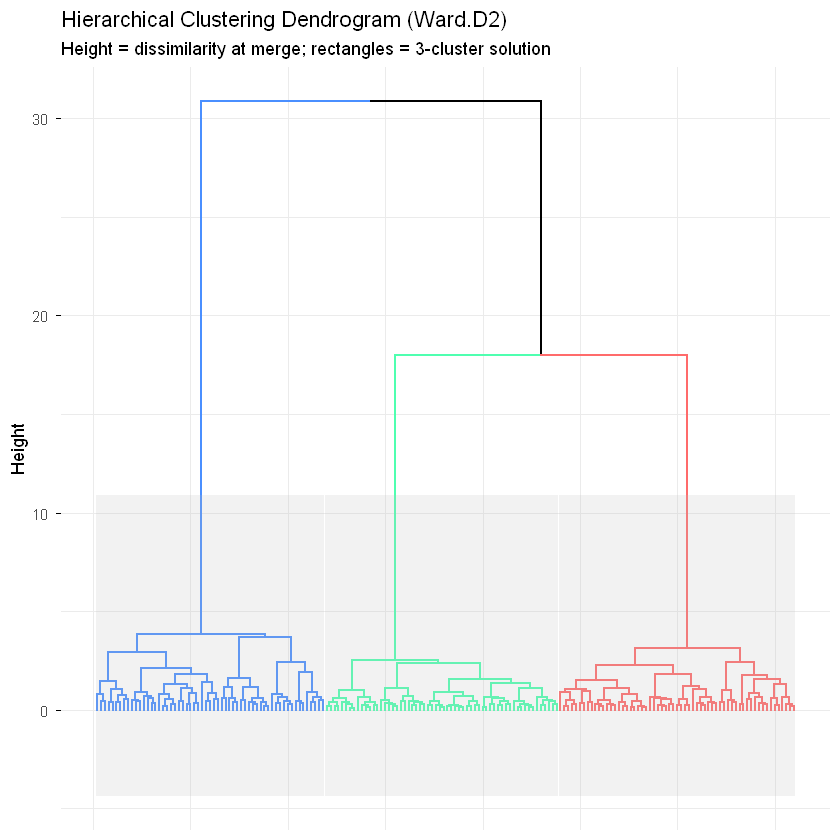

In [2]:
# Compute distance matrix and perform hierarchical clustering
dist_mat <- dist(X_scaled, method="euclidean")
hc_ward  <- hclust(dist_mat, method="ward.D2")

# ── Full dendrogram ───────────────────────────────────────────────────────────
factoextra::fviz_dend(
  hc_ward,
  k            = 3,              # colour by 3 clusters
  k_colors     = c("#4a8fff","#4fffb0","#ff6b6b"),
  rect         = TRUE,           # draw rectangles around clusters
  rect_fill    = TRUE,
  label_cols   = "transparent",  # hide leaf labels for n=180
  horiz        = FALSE,
  show_labels  = FALSE,
  ggtheme      = theme_minimal()
) +
  labs(title="Hierarchical Clustering Dendrogram (Ward.D2)",
       subtitle="Height = dissimilarity at merge; rectangles = 3-cluster solution")

# ── Cut tree at k=3 ───────────────────────────────────────────────────────────
clusters_ward <- cutree(hc_ward, k=3)
results <- hier_data %>% mutate(cluster=factor(clusters_ward))

# Agreement with true groups
table(cluster=results$cluster, true_group=results$group)

---

## Comparing Linkage Methods

# A tibble: 4 × 2
  method   cophenetic_r
  <chr>           <dbl>
1 complete        0.801
2 single          0.791
3 average         0.829
4 ward.D2         0.824


Loading required namespace: colorspace



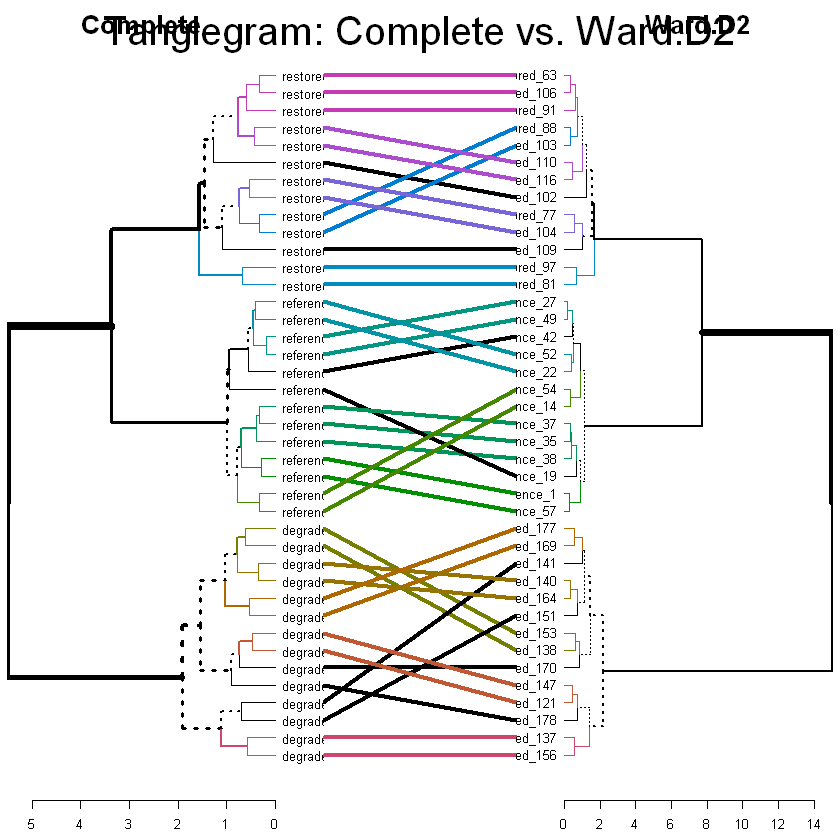

In [3]:
# Cophenetic correlation: how faithfully does the dendrogram represent distances?
# Higher = better representation of the original distance matrix
linkage_methods <- c("complete","single","average","ward.D2")

cophenetic_df <- map_dfr(linkage_methods, function(method) {
  hc   <- hclust(dist_mat, method=method)
  coph <- cor(dist_mat, cophenetic(hc))
  tibble(method=method, cophenetic_r=round(coph, 4))
})

print(cophenetic_df)
# Highest cophenetic correlation = linkage that best preserves distances
# Ward.D2 often has lower cophenetic r but produces more compact clusters

# ── Tanglegram: compare two dendrogram solutions ──────────────────────────────
# Subset to 40 observations for readability
idx_sub     <- sample(nrow(X_scaled), 40)
dist_sub    <- dist(X_scaled[idx_sub,])
hc_complete <- as.dendrogram(hclust(dist_sub, method="complete"))
hc_ward_sub <- as.dendrogram(hclust(dist_sub, method="ward.D2"))

dendextend::tanglegram(
  hc_complete, hc_ward_sub,
  highlight_distinct_edges = TRUE,
  common_subtrees_color_branches = TRUE,
  main="Tanglegram: Complete vs. Ward.D2",
  main_left="Complete", main_right="Ward.D2"
)
# Crossing lines = observations that move between methods
# Many crossings = results are linkage-sensitive

---

## Mixed-Type Data: Gower Distance

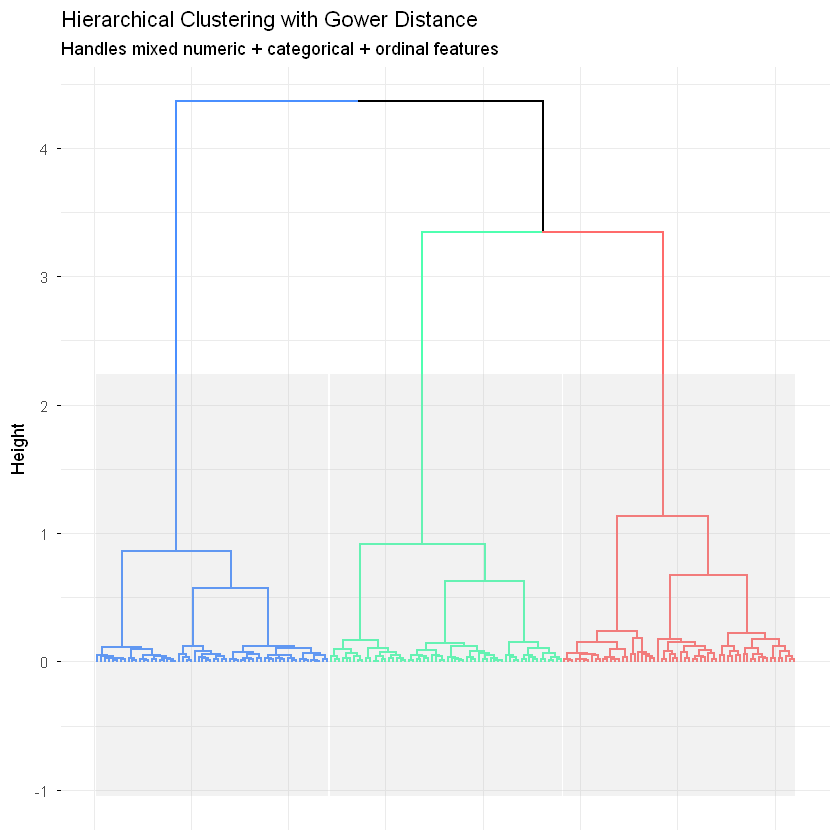

In [4]:
# Gower distance handles continuous + categorical + ordinal variables
# Essential when clustering sites with both numeric measurements and categorical types

mixed_data <- hier_data %>%
  select(nitrate, water_qual, phosphorus, group) %>%
  mutate(
    habitat_type = factor(group),
    disturbance  = ordered(sample(c("low","medium","high"), nrow(hier_data),
                                  replace=TRUE), levels=c("low","medium","high"))
  ) %>%
  select(-group)

# Gower distance — normalises each variable to [0,1] before computing distances
gower_dist <- cluster::daisy(mixed_data, metric="gower")

hc_gower <- hclust(as.dist(gower_dist), method="ward.D2")

factoextra::fviz_dend(
  hc_gower, k=3, show_labels=FALSE,
  k_colors  = c("#4a8fff","#4fffb0","#ff6b6b"),
  rect=TRUE, rect_fill=TRUE, ggtheme=theme_minimal()
) +
  labs(title="Hierarchical Clustering with Gower Distance",
       subtitle="Handles mixed numeric + categorical + ordinal features")

---

## Common Pitfalls

**1. Using single linkage for most clustering tasks**  
Single linkage suffers from "chaining" — clusters grow by adding single observations at a time, producing elongated chains rather than compact groups. It is useful for detecting outliers but almost never the right choice for finding natural groupings. Use Ward.D2 or average linkage as defaults.

**2. Not checking the cophenetic correlation**  
The cophenetic correlation measures how faithfully the dendrogram represents the original pairwise distances. If it is below 0.75, the dendrogram is a poor representation and conclusions drawn from it are unreliable. Try alternative linkage methods or check for outliers distorting the structure.

**3. Using Euclidean distance with mixed-type data**  
Euclidean distance has no sensible interpretation for categorical or ordinal variables. For datasets with mixed feature types, use Gower distance via `cluster::daisy()`, which normalises each variable type appropriately.

**4. Cutting the dendrogram at an arbitrary height without validation**  
The "right" cut height should be guided by a large vertical gap in the dendrogram (suggesting a natural grouping), validated with silhouette scores, and checked against domain knowledge. Choosing k solely because a plot looks approximately right is not sufficient.

**5. Applying hierarchical clustering to very large datasets**  
Computing the full distance matrix requires O(n²) memory and O(n² log n) computation. For n > 5000, consider `cluster::diana()` (divisive, faster), approximate hierarchical methods, or clustering a representative subsample first.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*